In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Part A – Conceptual Foundation (Theory)

### Q1. What is Regularization?

Regularization is a machine learning technique used to reduce overfitting by adding a penalty term to the model's loss function. It helps improve model generalization on unseen data.

### Q2. Difference between Ridge and Lasso Regression

• Ridge Regression (L2) reduces the magnitude of coefficients but does not make them zero.

• Lasso Regression (L1) reduces coefficients and can make some coefficients exactly zero, which performs feature selection.

### Q3. What is Cross Validation?

Cross Validation is a resampling technique used to evaluate machine learning models. It divides the dataset into multiple parts for training and validation to estimate model performance.

### Q4. Types of Cross Validation

1. K-Fold Cross Validation
The dataset is divided into K equal folds. Each fold is used once as testing data.

2. Stratified K-Fold
Maintains the same distribution of the target variable in every fold.

3. Leave-One-Out Cross Validation (LOOCV)
Uses one sample for testing and all remaining samples for training.

4. TimeSeriesSplit
Maintains chronological order while splitting time-series datasets.

### Q5. Why Tree-Based Models do not require Feature Scaling?

Tree-based models split data based on feature values rather than distance calculations. Therefore, feature scaling is not required.

# Part B – Dataset Understanding & Preparation

In [2]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Advanced_Regression_HousePrice_Dataset_3800 .csv")

In [3]:
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,01-01-2014,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,01-12-2019,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,01-10-2016,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,01-03-2013,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,01-07-2013,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [4]:
df.shape

(3800, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


In [6]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


In [7]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [17]:
# Convert sale_date into datetime

df["sale_date"] = pd.to_datetime(df["sale_date"])

In [18]:
# Extract year and month

df["sale_year"] = df["sale_date"].dt.year
df["sale_month"] = df["sale_date"].dt.month

In [19]:
# Drop sale_date

df.drop("sale_date", axis=1, inplace=True)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Features and Target

X = df.drop("house_price_inr", axis=1)

y = df["house_price_inr"]

X.head()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,sale_year,sale_month
0,200001,2181,6,4,8.1,21,3.8,0,0,4.84,2014,1
1,200002,2383,5,4,5.3,28,10.9,1,1,2.89,2019,1
2,200003,1047,3,3,5.9,7,27.5,0,1,4.04,2016,1
3,200004,1753,4,3,7.0,27,12.1,0,0,3.28,2013,1
4,200005,1728,4,4,10.0,32,1.4,0,1,3.84,2013,1


In [22]:
y.head()

0    35154898
1    26710893
2    11216242
3    21984310
4    25080429
Name: house_price_inr, dtype: int64

In [23]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape)
print(X_test.shape)

(3040, 12)
(760, 12)


In [24]:
# Create scaler

scaler = StandardScaler()

# Scale training data

X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data

X_test_scaled = scaler.transform(X_test)

In [25]:
print("Training Features :", X_train_scaled.shape)

print("Testing Features :", X_test_scaled.shape)

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (3040, 12)
Testing Features : (760, 12)
Training Target : (3040,)
Testing Target : (760,)


In [26]:
# Create Ridge model

ridge = Ridge()

# Train model

ridge.fit(X_train_scaled, y_train)

# Predictions

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

In [27]:
# Training Metrics

ridge_train_mae = mean_absolute_error(y_train, ridge_train_pred)
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_train_pred))
ridge_train_r2 = r2_score(y_train, ridge_train_pred)

# Testing Metrics

ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

print("RIDGE TRAIN RESULTS")
print("MAE :", ridge_train_mae)
print("RMSE :", ridge_train_rmse)
print("R2 :", ridge_train_r2)

print()

print("RIDGE TEST RESULTS")
print("MAE :", ridge_test_mae)
print("RMSE :", ridge_test_rmse)
print("R2 :", ridge_test_r2)

RIDGE TRAIN RESULTS
MAE : 1895595.0961808825
RMSE : 2481601.612014244
R2 : 0.9174547512277476

RIDGE TEST RESULTS
MAE : 1945339.404630282
RMSE : 2539485.5123174908
R2 : 0.9199233487434338


In [28]:
param_grid = {
    "alpha":[0.001,0.01,0.1,1,10,50,100]
}

ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring="r2",
    cv=5
)

ridge_grid.fit(X_train_scaled,y_train)

print("Best Alpha :", ridge_grid.best_params_)
print("Best CV Score :", ridge_grid.best_score_)

Best Alpha : {'alpha': 1}
Best CV Score : 0.9164416096791396


In [29]:
best_ridge = ridge_grid.best_estimator_

best_ridge.fit(X_train_scaled,y_train)

ridge_pred = best_ridge.predict(X_test_scaled)

print("Best Ridge R2 :",r2_score(y_test,ridge_pred))
print("Best Ridge RMSE :",np.sqrt(mean_squared_error(y_test,ridge_pred)))

Best Ridge R2 : 0.9199233487434338
Best Ridge RMSE : 2539485.5123174908


In [30]:
lasso = Lasso()

lasso.fit(X_train_scaled,y_train)

lasso_train_pred = lasso.predict(X_train_scaled)

lasso_test_pred = lasso.predict(X_test_scaled)

In [31]:
lasso_train_mae = mean_absolute_error(y_train,lasso_train_pred)
lasso_train_rmse = np.sqrt(mean_squared_error(y_train,lasso_train_pred))
lasso_train_r2 = r2_score(y_train,lasso_train_pred)

lasso_test_mae = mean_absolute_error(y_test,lasso_test_pred)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test,lasso_test_pred))
lasso_test_r2 = r2_score(y_test,lasso_test_pred)

print("LASSO TRAIN RESULTS")
print("MAE :",lasso_train_mae)
print("RMSE :",lasso_train_rmse)
print("R2 :",lasso_train_r2)

print()

print("LASSO TEST RESULTS")
print("MAE :",lasso_test_mae)
print("RMSE :",lasso_test_rmse)
print("R2 :",lasso_test_r2)

LASSO TRAIN RESULTS
MAE : 1895704.2752396506
RMSE : 2481597.8065379984
R2 : 0.9174550043898514

LASSO TEST RESULTS
MAE : 1945475.0528828457
RMSE : 2539256.5715555917
R2 : 0.9199377863002434


In [32]:
lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=param_grid,
    scoring="r2",
    cv=5
)

lasso_grid.fit(X_train_scaled,y_train)

print("Best Alpha :",lasso_grid.best_params_)
print("Best Score :",lasso_grid.best_score_)

Best Alpha : {'alpha': 100}
Best Score : 0.9164410346360885


In [33]:
best_lasso = lasso_grid.best_estimator_

best_lasso.fit(X_train_scaled,y_train)

lasso_pred = best_lasso.predict(X_test_scaled)

print("Best Lasso R2 :",r2_score(y_test,lasso_pred))
print("Best Lasso RMSE :",np.sqrt(mean_squared_error(y_test,lasso_pred)))

Best Lasso R2 : 0.919936457417873
Best Lasso RMSE : 2539277.6449130094


In [34]:
comparison = pd.DataFrame({
    "Model":["Ridge","Lasso"],
    "MAE":[
        mean_absolute_error(y_test,ridge_pred),
        mean_absolute_error(y_test,lasso_pred)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,ridge_pred)),
        np.sqrt(mean_squared_error(y_test,lasso_pred))
    ],
    "R2":[
        r2_score(y_test,ridge_pred),
        r2_score(y_test,lasso_pred)
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Ridge,1.945339e+06,2.539486e+06,0.919923
1,Lasso,1.945482e+06,2.539278e+06,0.919936


In [35]:
coef = pd.DataFrame({
    "Feature":X.columns,
    "Ridge":best_ridge.coef_,
    "Lasso":best_lasso.coef_
})

coef

,Feature,Ridge,Lasso
0,property_id,-6.522333e+04,-6.524917e+04
1,area_sqft,6.950163e+06,6.957472e+06
2,bedrooms,2.933896e+05,2.872064e+05
3,bathrooms,2.731628e+05,2.732051e+05
4,location_score,3.682017e+06,3.684070e+06
5,property_age,-6.503727e+05,-6.504607e+05
6,distance_city_km,-2.633428e+04,-2.489680e+04
7,near_school,1.305095e+04,1.288001e+04
8,near_metro,5.282576e+04,5.281505e+04
9,crime_rate_index,-1.397355e+05,-1.395738e+05


In [36]:
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_val_score
)

In [37]:
# K-Fold Cross Validation

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ridge_kfold = cross_val_score(
    best_ridge,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring="r2"
)

print("K-Fold Scores")
print(ridge_kfold)

print("\nAverage R² :", ridge_kfold.mean())

K-Fold Scores
[0.91948417 0.90758653 0.91439795 0.92057786 0.91975826]

Average R² : 0.9163609525867932


In [38]:
# Create target bins

y_bins = pd.qcut(
    y_train,
    q=5,
    labels=False,
    duplicates="drop"
)

In [39]:
# Stratified K-Fold

stratified = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ridge_stratified = cross_val_score(
    best_ridge,
    X_train_scaled,
    y_train,
    cv=stratified.split(X_train_scaled, y_bins),
    scoring="r2"
)

print("Stratified Scores")
print(ridge_stratified)

print("\nAverage R² :", ridge_stratified.mean())

Stratified Scores
[0.91134283 0.92323824 0.91786047 0.91892864 0.91270613]

Average R² : 0.916815264348284


In [40]:
df_time = df.sort_values(
    by=["sale_year", "sale_month"]
).reset_index(drop=True)

In [41]:
X_time = df_time.drop("house_price_inr", axis=1)
y_time = df_time["house_price_inr"]

In [42]:
# Scale features

X_time_scaled = scaler.fit_transform(X_time)

In [43]:
tscv = TimeSeriesSplit(n_splits=5)

ridge_time = cross_val_score(
    best_ridge,
    X_time_scaled,
    y_time,
    cv=tscv,
    scoring="r2"
)

print("Time Series Scores")

print(ridge_time)

print("\nAverage R² :", ridge_time.mean())

Time Series Scores
[0.91239497 0.91542402 0.92369619 0.91261017 0.92094411]

Average R² : 0.917013890887788


In [44]:
cv_results = pd.DataFrame({

    "Method":[
        "K-Fold",
        "Stratified K-Fold",
        "Time Series"
    ],

    "Average R²":[

        ridge_kfold.mean(),

        ridge_stratified.mean(),

        ridge_time.mean()
    ]

})

cv_results

,Method,Average R²
0,K-Fold,0.916361
1,Stratified K-Fold,0.916815
2,Time Series,0.917014


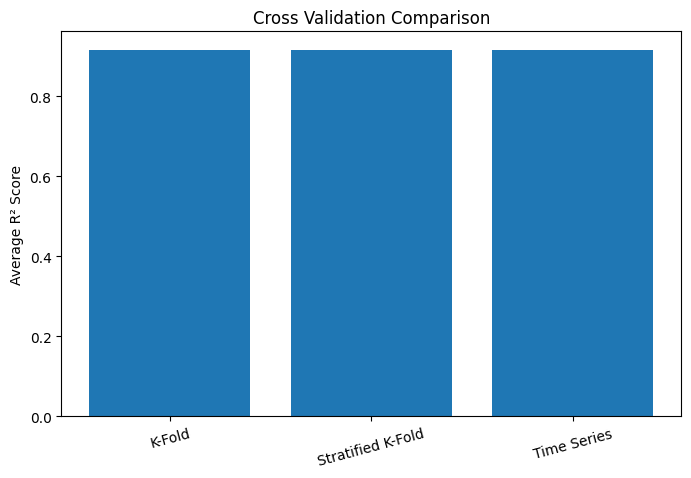

In [45]:
plt.figure(figsize=(8,5))

plt.bar(
    cv_results["Method"],
    cv_results["Average R²"]
)

plt.title("Cross Validation Comparison")

plt.ylabel("Average R² Score")

plt.xticks(rotation=15)

plt.show()

In [46]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [47]:
# Create Decision Tree model

dt_model = DecisionTreeRegressor(random_state=42)

# Train the model

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [48]:
dt_train_pred = dt_model.predict(X_train)

dt_test_pred = dt_model.predict(X_test)

In [49]:
print("Decision Tree Performance")

print("Training R² :", r2_score(y_train, dt_train_pred))
print("Testing R² :", r2_score(y_test, dt_test_pred))

print("Training RMSE :", np.sqrt(mean_squared_error(y_train, dt_train_pred)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, dt_test_pred)))

print("Training MAE :", mean_absolute_error(y_train, dt_train_pred))
print("Testing MAE :", mean_absolute_error(y_test, dt_test_pred))

Decision Tree Performance
Training R² : 1.0
Testing R² : 0.8657651131038511
Training RMSE : 0.0
Testing RMSE : 3287952.150564807
Training MAE : 0.0
Testing MAE : 2409517.3710526316


In [50]:
param_grid = {

    "max_depth":[3,5,7,10,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

grid_dt = GridSearchCV(

    estimator=DecisionTreeRegressor(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid_dt.fit(X_train, y_train)

print("Best Parameters :", grid_dt.best_params_)

print("Best CV Score :", grid_dt.best_score_)

Best Parameters : {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score : 0.8950516043364951


In [51]:
best_dt = grid_dt.best_estimator_

best_dt.fit(X_train, y_train)

best_dt_pred = best_dt.predict(X_test)

print("Best Decision Tree R² :", r2_score(y_test, best_dt_pred))

print("Best Decision Tree RMSE :", np.sqrt(mean_squared_error(y_test, best_dt_pred)))

Best Decision Tree R² : 0.9059496507291006
Best Decision Tree RMSE : 2752155.664717511


In [52]:
rf_model = RandomForestRegressor(

    random_state=42,

    n_estimators=100

)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [53]:
rf_train_pred = rf_model.predict(X_train)

rf_test_pred = rf_model.predict(X_test)

In [54]:
print("Random Forest Performance")

print("Training R² :", r2_score(y_train, rf_train_pred))
print("Testing R² :", r2_score(y_test, rf_test_pred))

print("Training RMSE :", np.sqrt(mean_squared_error(y_train, rf_train_pred)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, rf_test_pred)))

print("Training MAE :", mean_absolute_error(y_train, rf_train_pred))
print("Testing MAE :", mean_absolute_error(y_test, rf_test_pred))

Random Forest Performance
Training R² : 0.9893756285121044
Testing R² : 0.9266375692160109
Training RMSE : 890302.608977193
Testing RMSE : 2430690.3926006434
Training MAE : 661762.0380131579
Testing MAE : 1780924.7067105263


In [55]:
rf_param = {

    "n_estimators":[100,200],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

grid_rf = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=rf_param,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid_rf.fit(X_train, y_train)

print("Best Parameters :", grid_rf.best_params_)

print("Best CV Score :", grid_rf.best_score_)

Best Parameters : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score : 0.9231402904599193


In [56]:
best_rf = grid_rf.best_estimator_

best_rf.fit(X_train, y_train)

rf_best_pred = best_rf.predict(X_test)

print("Best Random Forest R² :", r2_score(y_test, rf_best_pred))

print("Best Random Forest RMSE :", np.sqrt(mean_squared_error(y_test, rf_best_pred)))

Best Random Forest R² : 0.9280617912960181
Best Random Forest RMSE : 2406980.6435289346


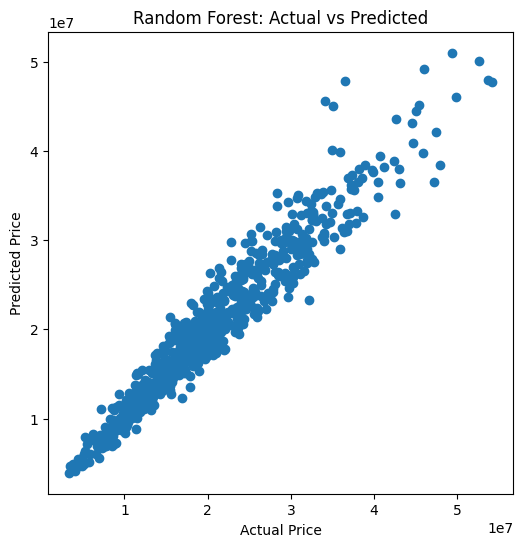

In [57]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_best_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [58]:
tree_results = pd.DataFrame({

    "Model":["Decision Tree","Random Forest"],

    "MAE":[

        mean_absolute_error(y_test, best_dt_pred),

        mean_absolute_error(y_test, rf_best_pred)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test, best_dt_pred)),

        np.sqrt(mean_squared_error(y_test, rf_best_pred))

    ],

    "R²":[

        r2_score(y_test, best_dt_pred),

        r2_score(y_test, rf_best_pred)

    ]

})

tree_results

,Model,MAE,RMSE,R²
0,Decision Tree,2.023710e+06,2.752156e+06,0.905950
1,Random Forest,1.757590e+06,2.406981e+06,0.928062


In [59]:
print("Decision Tree")

print("Training R² :", r2_score(y_train, best_dt.predict(X_train)))

print("Testing R² :", r2_score(y_test, best_dt.predict(X_test)))

print("\nRandom Forest")

print("Training R² :", r2_score(y_train, best_rf.predict(X_train)))

print("Testing R² :", r2_score(y_test, best_rf.predict(X_test)))

Decision Tree
Training R² : 0.9362686340010182
Testing R² : 0.9059496507291006

Random Forest
Training R² : 0.9769782258139262
Testing R² : 0.9280617912960181


In [60]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [61]:
# Create Linear SVR model

linear_svr = SVR(kernel="linear")

# Train model

linear_svr.fit(X_train_scaled, y_train)


SVR(kernel='linear')

In [62]:
# Predictions

linear_train_pred = linear_svr.predict(X_train_scaled)

linear_test_pred = linear_svr.predict(X_test_scaled)

In [63]:
print("Linear SVR Performance")

print("Training R² :", r2_score(y_train, linear_train_pred))
print("Testing R² :", r2_score(y_test, linear_test_pred))

print("Training RMSE :", np.sqrt(mean_squared_error(y_train, linear_train_pred)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, linear_test_pred)))

print("Training MAE :", mean_absolute_error(y_train, linear_train_pred))
print("Testing MAE :", mean_absolute_error(y_test, linear_test_pred))

Linear SVR Performance
Training R² : -0.005826260277332684
Testing R² : -0.0019126647991076773
Training RMSE : 8662584.963565966
Testing RMSE : 8982717.07782501
Training MAE : 6835463.1560768625
Testing MAE : 6990273.726881434


In [64]:
rbf_svr = SVR(kernel="rbf")

rbf_svr.fit(X_train_scaled, y_train)

SVR()

In [65]:
rbf_train_pred = rbf_svr.predict(X_train_scaled)

rbf_test_pred = rbf_svr.predict(X_test_scaled)

In [66]:
print("RBF SVR Performance")

print("Training R² :", r2_score(y_train, rbf_train_pred))
print("Testing R² :", r2_score(y_test, rbf_test_pred))

print("Training RMSE :", np.sqrt(mean_squared_error(y_train, rbf_train_pred)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, rbf_test_pred)))

print("Training MAE :", mean_absolute_error(y_train, rbf_train_pred))
print("Testing MAE :", mean_absolute_error(y_test, rbf_test_pred))

RBF SVR Performance
Training R² : -0.006889280363662209
Testing R² : -0.0029465164315989334
Training RMSE : 8667161.3354674
Testing RMSE : 8987350.416920451
Training MAE : 6839196.906666788
Testing MAE : 6994046.692252502


In [67]:
param_grid = {

    "C":[0.1,1,10,100],

    "epsilon":[0.01,0.1,0.5,1],

    "gamma":["scale","auto"]

}

grid_svr = GridSearchCV(

    estimator=SVR(kernel="rbf"),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid_svr.fit(X_train_scaled, y_train)

print("Best Parameters :", grid_svr.best_params_)

print("Best Cross Validation Score :", grid_svr.best_score_)

Best Parameters : {'C': 100, 'epsilon': 1, 'gamma': 'auto'}
Best Cross Validation Score : -0.00656609864518114


In [68]:
best_svr = grid_svr.best_estimator_

best_svr.fit(X_train_scaled, y_train)

best_svr_pred = best_svr.predict(X_test_scaled)

print("Best SVR R² :", r2_score(y_test, best_svr_pred))

print("Best SVR RMSE :", np.sqrt(mean_squared_error(y_test, best_svr_pred)))

print("Best SVR MAE :", mean_absolute_error(y_test, best_svr_pred))

Best SVR R² : -0.0004830958965009735
Best SVR RMSE : 8976306.340952696
Best SVR MAE : 6984906.425628092


In [69]:
svr_results = pd.DataFrame({

    "Model":["Linear SVR","RBF SVR"],

    "MAE":[

        mean_absolute_error(y_test, linear_test_pred),

        mean_absolute_error(y_test, best_svr_pred)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test, linear_test_pred)),

        np.sqrt(mean_squared_error(y_test, best_svr_pred))

    ],

    "R²":[

        r2_score(y_test, linear_test_pred),

        r2_score(y_test, best_svr_pred)

    ]

})

svr_results

,Model,MAE,RMSE,R²
0,Linear SVR,6.990274e+06,8.982717e+06,-0.001913
1,RBF SVR,6.984906e+06,8.976306e+06,-0.000483


In [70]:
print("========== SVR SUMMARY ==========")

print("Linear SVR R² :", r2_score(y_test, linear_test_pred))
print("RBF SVR R² :", r2_score(y_test, best_svr_pred))

print("Linear SVR RMSE :", np.sqrt(mean_squared_error(y_test, linear_test_pred)))
print("RBF SVR RMSE :", np.sqrt(mean_squared_error(y_test, best_svr_pred)))

print("Linear SVR MAE :", mean_absolute_error(y_test, linear_test_pred))
print("RBF SVR MAE :", mean_absolute_error(y_test, best_svr_pred))

========== SVR SUMMARY ==========
Linear SVR R² : -0.0019126647991076773
RBF SVR R² : -0.0004830958965009735
Linear SVR RMSE : 8982717.07782501
RBF SVR RMSE : 8976306.340952696
Linear SVR MAE : 6990273.726881434
RBF SVR MAE : 6984906.425628092


In [71]:
# Compare all models

final_results = pd.DataFrame({

    "Model":[
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Regression"
    ],

    "MAE":[

        mean_absolute_error(y_test, ridge_pred),

        mean_absolute_error(y_test, lasso_pred),

        mean_absolute_error(y_test, best_dt_pred),

        mean_absolute_error(y_test, rf_best_pred),

        mean_absolute_error(y_test, best_svr_pred)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test, ridge_pred)),

        np.sqrt(mean_squared_error(y_test, lasso_pred)),

        np.sqrt(mean_squared_error(y_test, best_dt_pred)),

        np.sqrt(mean_squared_error(y_test, rf_best_pred)),

        np.sqrt(mean_squared_error(y_test, best_svr_pred))

    ],

    "R² Score":[

        r2_score(y_test, ridge_pred),

        r2_score(y_test, lasso_pred),

        r2_score(y_test, best_dt_pred),

        r2_score(y_test, rf_best_pred),

        r2_score(y_test, best_svr_pred)

    ]

})

final_results

,Model,MAE,RMSE,R² Score
0,Ridge Regression,1.945339e+06,2.539486e+06,0.919923
1,Lasso Regression,1.945482e+06,2.539278e+06,0.919936
2,Decision Tree,2.023710e+06,2.752156e+06,0.905950
3,Random Forest,1.757590e+06,2.406981e+06,0.928062
4,Support Vector Regression,6.984906e+06,8.976306e+06,-0.000483


In [72]:
final_results = final_results.sort_values(
    by="R² Score",
    ascending=False
)

final_results

,Model,MAE,RMSE,R² Score
3,Random Forest,1.757590e+06,2.406981e+06,0.928062
1,Lasso Regression,1.945482e+06,2.539278e+06,0.919936
0,Ridge Regression,1.945339e+06,2.539486e+06,0.919923
2,Decision Tree,2.023710e+06,2.752156e+06,0.905950
4,Support Vector Regression,6.984906e+06,8.976306e+06,-0.000483


In [73]:
print("Best Model")

print(final_results.iloc[0])

Best Model
Model        Random Forest
MAE         1757590.116983
RMSE        2406980.643529
R² Score          0.928062
Name: 3, dtype: object


In [74]:
comparison = pd.DataFrame({

    "Model":[
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest",
        "SVR"
    ],

    "Training R²":[

        r2_score(y_train, best_ridge.predict(X_train_scaled)),

        r2_score(y_train, best_lasso.predict(X_train_scaled)),

        r2_score(y_train, best_dt.predict(X_train)),

        r2_score(y_train, best_rf.predict(X_train)),

        r2_score(y_train, best_svr.predict(X_train_scaled))

    ],

    "Testing R²":[

        r2_score(y_test, ridge_pred),

        r2_score(y_test, lasso_pred),

        r2_score(y_test, best_dt_pred),

        r2_score(y_test, rf_best_pred),

        r2_score(y_test, best_svr_pred)

    ]

})

comparison

,Model,Training R²,Testing R²
0,Ridge,0.917455,0.919923
1,Lasso,0.917455,0.919936
2,Decision Tree,0.936269,0.905950
3,Random Forest,0.976978,0.928062
4,SVR,-0.004260,-0.000483


In [75]:
for i in range(len(comparison)):

    print("--------------------------------")

    print(comparison.iloc[i]["Model"])

    print("Training R² :", comparison.iloc[i]["Training R²"])

    print("Testing R² :", comparison.iloc[i]["Testing R²"])

    difference = comparison.iloc[i]["Training R²"] - comparison.iloc[i]["Testing R²"]

    print("Difference :", difference)

--------------------------------
Ridge
Training R² : 0.9174547512277476
Testing R² : 0.9199233487434338
Difference : -0.0024685975156862883
--------------------------------
Lasso
Training R² : 0.9174550032843087
Testing R² : 0.919936457417873
Difference : -0.002481454133564265
--------------------------------
Decision Tree
Training R² : 0.9362686340010182
Testing R² : 0.9059496507291006
Difference : 0.03031898327191762
--------------------------------
Random Forest
Training R² : 0.9769782258139262
Testing R² : 0.9280617912960181
Difference : 0.04891643451790817
--------------------------------
SVR
Training R² : -0.004260294996661251
Testing R² : -0.0004830958965009735
Difference : -0.003777199100160278


In [76]:
print("========== FINAL SUMMARY ==========")

print(final_results)

print("\nBest Performing Model :")

print(final_results.iloc[0]["Model"])

print("\nHighest R² Score :")

print(final_results.iloc[0]["R² Score"])

========== FINAL SUMMARY ==========
                       Model           MAE          RMSE  R² Score
3              Random Forest  1.757590e+06  2.406981e+06  0.928062
1           Lasso Regression  1.945482e+06  2.539278e+06  0.919936
0           Ridge Regression  1.945339e+06  2.539486e+06  0.919923
2              Decision Tree  2.023710e+06  2.752156e+06  0.905950
4  Support Vector Regression  6.984906e+06  8.976306e+06 -0.000483

Best Performing Model :
Random Forest

Highest R² Score :
0.9280617912960181
